In [25]:
import pandas as pd
import numpy as np
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\Development-jourey\\machinelearningworks\\Feature_engineering\\loan_data\\5_6062406197263211278.csv")

In [26]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [27]:
df.shape
df[" loan_status"].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [29]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [30]:
x= df.iloc[:,1:-1]
y= df.iloc[:,-1]

In [31]:
x

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...
4264,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [32]:
y.head()

0     Approved
1     Rejected
2     Rejected
3     Rejected
4     Rejected
Name:  loan_status, dtype: object

In [33]:
#null value managing
from sklearn.impute import SimpleImputer
impute = SimpleImputer(missing_values=np.nan,strategy="mean")
x.iloc[:,3:]= impute.fit_transform(x.iloc[:,3:])


In [34]:
#x.iloc[:,0]= impute.fit_transform(x.iloc[:,0])

In [35]:
#encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
xe = ColumnTransformer([("encoder",OneHotEncoder(),[1])],remainder="passthrough")
x=pd.DataFrame(xe.fit_transform(x))
# ct = ColumnTransformer([("endcoder",OneHotEncoder(),[0])],remainder="passthrough")
# X=pd.DataFrame(ct.fit_transform(X))

x



,0,1,2,3,4,5,6,7,8,9,10,11
0,1.0,0.0,2,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0.0,1.0,0,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,1.0,0.0,3,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,1.0,0.0,3,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,0.0,1.0,5,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,1.0,0.0,5,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,0.0,1.0,0,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,0.0,1.0,2,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,0.0,1.0,1,No,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [36]:
xee = ColumnTransformer([("encoder",OneHotEncoder(),[3])],remainder="passthrough")
x=pd.DataFrame(xee.fit_transform(x))

In [37]:
x

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.0,0.0,1.0,0.0,2,9600000,29900000,12,778,2400000,17600000,22700000,8000000
1,0.0,1.0,0.0,1.0,0,4100000,12200000,8,417,2700000,2200000,8800000,3300000
2,1.0,0.0,1.0,0.0,3,9100000,29700000,20,506,7100000,4500000,33300000,12800000
3,1.0,0.0,1.0,0.0,3,8200000,30700000,8,467,18200000,3300000,23300000,7900000
4,0.0,1.0,0.0,1.0,5,9800000,24200000,20,382,12400000,8200000,29400000,5000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,0.0,1.0,1.0,0.0,5,1000000,2300000,12,317,2800000,500000,3300000,800000
4265,0.0,1.0,0.0,1.0,0,3300000,11300000,20,559,4200000,2900000,11000000,1900000
4266,1.0,0.0,0.0,1.0,2,6500000,23900000,18,457,1200000,12400000,18100000,7300000
4267,1.0,0.0,0.0,1.0,1,4100000,12800000,8,780,8200000,700000,14100000,5800000


In [38]:
# labelencoder 
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
y = le.fit_transform(y)
y

array([0, 1, 1, ..., 1, 0, 0], shape=(4269,))

In [39]:
#train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [40]:
x_train

,0,1,2,3,4,5,6,7,8,9,10,11,12
1675,1.0,0.0,0.0,1.0,5,7900000,29900000,6,568,5800000,13900000,15900000,8700000
1164,0.0,1.0,0.0,1.0,0,9600000,34000000,12,710,23800000,10300000,38100000,7800000
192,1.0,0.0,1.0,0.0,1,800000,2900000,8,682,2200000,1100000,2900000,700000
910,0.0,1.0,1.0,0.0,2,4900000,13100000,18,754,8200000,3300000,16500000,7200000
567,0.0,1.0,1.0,0.0,5,3000000,11100000,12,441,8500000,2500000,7300000,2000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3444,0.0,1.0,1.0,0.0,0,1300000,4700000,16,530,3200000,1000000,3800000,800000
466,0.0,1.0,0.0,1.0,5,500000,1800000,18,411,1000000,500000,1300000,200000
3092,0.0,1.0,0.0,1.0,4,8600000,20600000,16,449,10800000,10600000,28700000,5400000
3772,0.0,1.0,0.0,1.0,2,7000000,21400000,12,541,3700000,1300000,19800000,9600000


In [41]:
#scalng
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
x_test= scaler.fit_transform(x_test)
x_train= scaler.fit_transform(x_train)

In [42]:
x_test

array([[1.        , 0.        , 1.        , ..., 0.53475936, 0.40583554,
        0.5106383 ],
       [1.        , 0.        , 1.        , ..., 0.50802139, 0.46153846,
        0.46808511],
       [1.        , 0.        , 1.        , ..., 0.86631016, 0.74535809,
        0.46099291],
       ...,
       [0.        , 1.        , 0.        , ..., 0.37967914, 0.29973475,
        0.54609929],
       [1.        , 0.        , 0.        , ..., 0.06951872, 0.14588859,
        0.09219858],
       [1.        , 0.        , 0.        , ..., 0.29946524, 0.24668435,
        0.12056738]], shape=(854, 13))

In [43]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [44]:
y_pred = knn.predict(x_test)
y_pred

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1,

In [45]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred,y_test))

0.8793911007025761


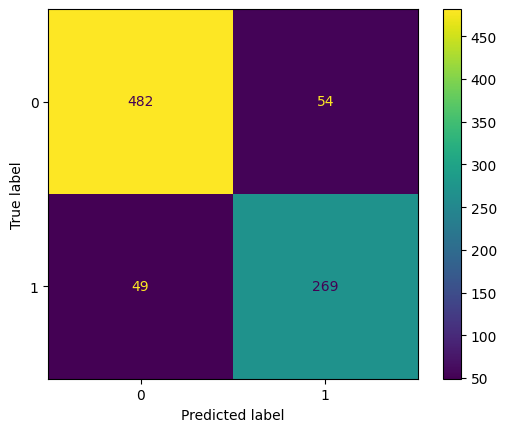

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

In [47]:
from sklearn.metrics import precision_score,recall_score,f1_score
print(f"precisio score{precision_score(y_test,y_pred)}")
print(f"recall score = {recall_score(y_test,y_pred)}")
print(f"f1 score = {f1_score(y_test,y_pred)}")

precisio score0.8328173374613003
recall score = 0.8459119496855346
f1 score = 0.8393135725429017
